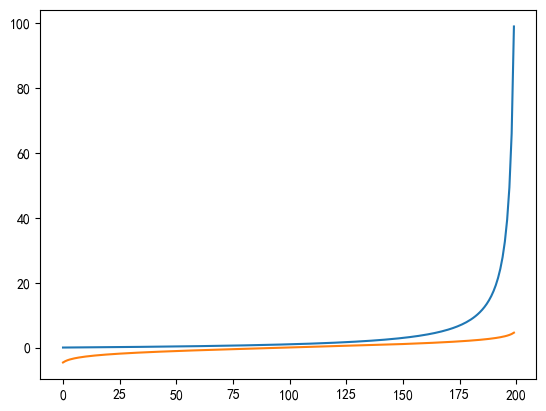

In [5]:
import numpy as np
import matplotlib.pyplot as plt
p1=np.linspace(0.01,0.99,200)
p0=1-p1
plt.plot(p1/p0)
plt.plot(np.log(p1/p0))


Text(0.5, 0, 'z')

Text(0, 0.5, 'sigmoid(z)')

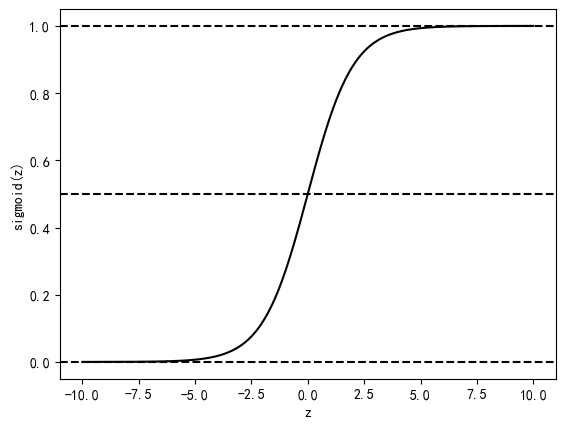

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z), c='k')
plt.axhline(ls="--", c='k')
plt.axhline(y=0.5, ls="--", c='k')
plt.axhline(y=1, ls="--", c='k')
plt.xlabel("z")
plt.ylabel("sigmoid(z)")

Text(0.5, 0, '$\\sigma(z)$')

Text(0, 0.5, 'loss')

Text(0.5, 1.0, '损失函数与$\\sigma(z)$的关系')

Text(0.5, 0, '$\\sigma(z)$')

Text(0, 0.5, 'loss')

Text(0.5, 1.0, '损失函数与$\\sigma(z)$的关系')

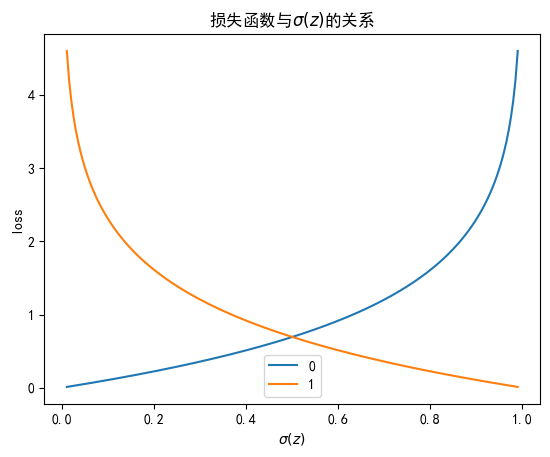

In [8]:
s=np.linspace(0.01,0.99,200)
for y in [0,1]:
    #计算对数损失函数的值
    loss=-y*np.log(s)-(1-y)*np.log(1-s)
    plt.plot(s,loss,label=f'{y}')
    plt.legend()
    plt.xlabel('$\sigma(z)$')
    plt.ylabel('loss')
    plt.title('损失函数与$\sigma(z)$的关系')

In [9]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X, y = iris.data, iris.target
print(X.shape, y.shape)
print(X[:5])
print(y[:5])
print(iris.feature_names)
print(iris.target_names)
# print(iris.DESCR)
print(np.unique(y))
print(pd.Series(y).value_counts())
# 返回从0开始，到数组中最大值为止，每个整数值出现的次数。
print(np.bincount(y))
print(np.bincount([0, 0, 5, 5, 5]))

(150, 4) (150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
[0 1 2]
0    50
1    50
2    50
Name: count, dtype: int64
[50 50 50]
[2 0 0 0 0 3]


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# return_X_y：是否仅返回X与y，默认为False。
X, y = load_iris(return_X_y=True)
# 我们这里取两个特征，两个类别。
X = X[y != 0, 2:]
y = y[y != 0]
# 习惯上，二分类的标签设置为0与1（非必须）。
y[y == 1] = 0
y[y == 2] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("权重：", lr.coef_)
print("偏置：", lr.intercept_)
y_pred = lr.predict(X_test)
print("真实值：", y_test)
print("预测值：", y_pred)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


权重： [[2.54334475 2.15611339]]
偏置： [-16.08373212]
真实值： [1 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]
预测值： [1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]


Text(0.5, 0, '花瓣长度')

Text(0, 0.5, '花瓣宽度')

Text(0.5, 1.0, '鸢尾花样本分布')

<Figure size 1500x500 with 0 Axes>

Text(0.5, 0, '样本序号')

Text(0, 0.5, '真值/预测值')

Text(0.5, 1.0, '逻辑回归结果可视化')

[[0.46966326 0.53033674]
 [0.98283042 0.01716958]
 [0.72577438 0.27422562]
 [0.91248826 0.08751174]
 [0.80289869 0.19710131]]
[1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]
[1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]


<Figure size 1000x500 with 0 Axes>

<BarContainer object of 25 artists>

<BarContainer object of 25 artists>

Text(0.5, 0, '样本索引')

Text(0, 0.5, '概率')

Text(0.5, 1.0, '逻辑回归分类概率')

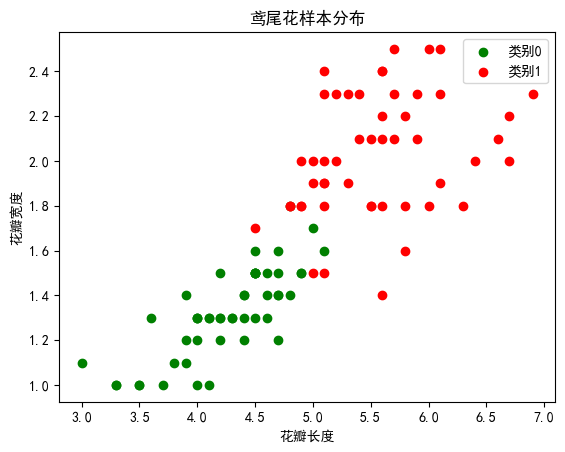

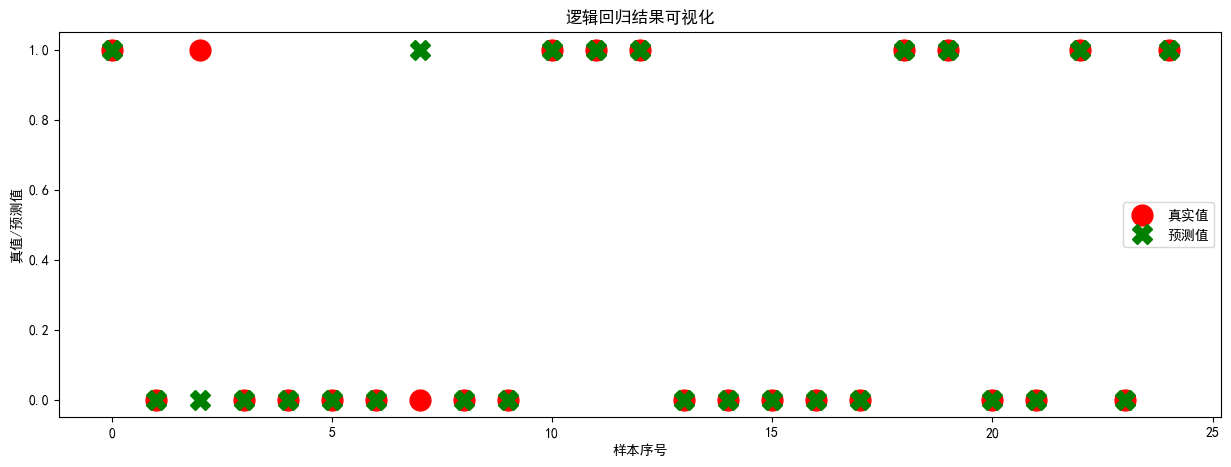

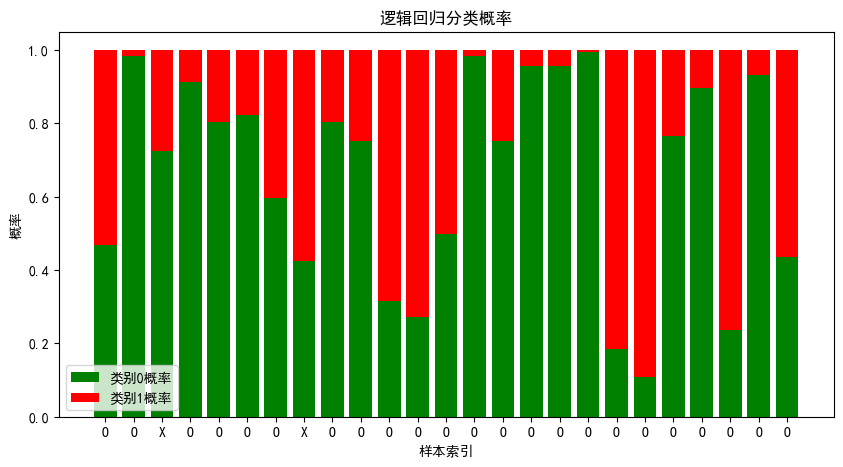

In [11]:
c1 = X[y == 0]
c2 = X[y == 1]
plt.scatter(c1[:, 0], c1[:, 1], c="g", label="类别0")
plt.scatter(c2[:, 0], c2[:, 1], c="r", label="类别1")
plt.xlabel("花瓣长度")
plt.ylabel("花瓣宽度")
plt.title("鸢尾花样本分布")
plt.legend()

plt.figure(figsize=(15, 5))
plt.plot(y_test, marker="o", ls="", ms=15, c="r", label="真实值")
plt.plot(y_pred, marker="X", ls="", ms=15, c="g", label="预测值")
plt.legend()
plt.xlabel("样本序号")
plt.ylabel("真值/预测值")
plt.title("逻辑回归结果可视化")


proba = lr.predict_proba(X_test)
print(proba[:5])
print(np.argmax(proba, axis=1))
print(lr.predict(X_test))

index = np.arange(X_test.shape[0])
proba_0 = proba[:, 0]
proba_1 = proba[:, 1]
tick_label = np.where(y_test == y_pred, "O", "X")
plt.figure(figsize=(10, 5))
plt.bar(index, height=proba_0, color="g", label="类别0概率")
plt.bar(index, height=proba_1, color="r", bottom=proba_0, label="类别1概率", tick_label=tick_label)
plt.legend()
plt.xlabel("样本索引")
plt.ylabel("概率")
plt.title("逻辑回归分类概率")